In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 


In [2]:
df = pd.read_csv('job_salary_prediction_dataset.csv')

In [3]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


<Axes: xlabel='job_title'>

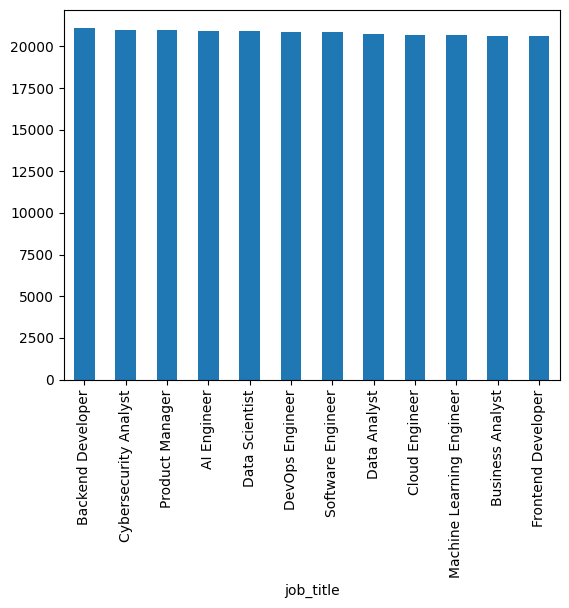

In [4]:
job_title_counts = df['job_title'].value_counts()
job_title_counts.plot(kind='bar')
    

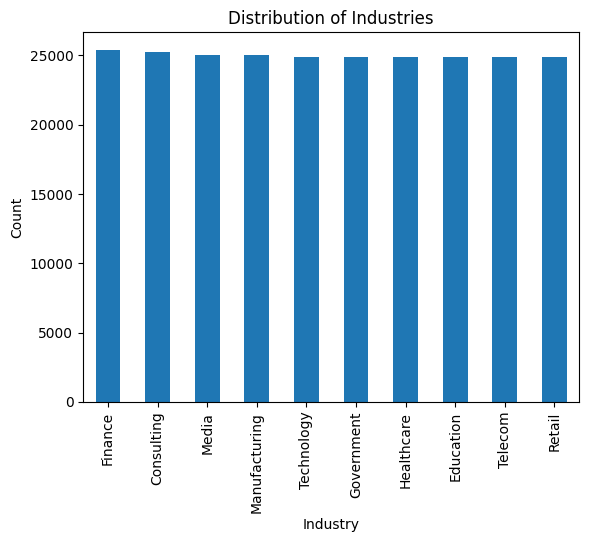

In [5]:
industry_counts = df['industry'].value_counts()
industry_counts.plot(kind='bar')
plt.xlabel('Industry')
plt.ylabel('Count')
plt.title('Distribution of Industries')
plt.show()

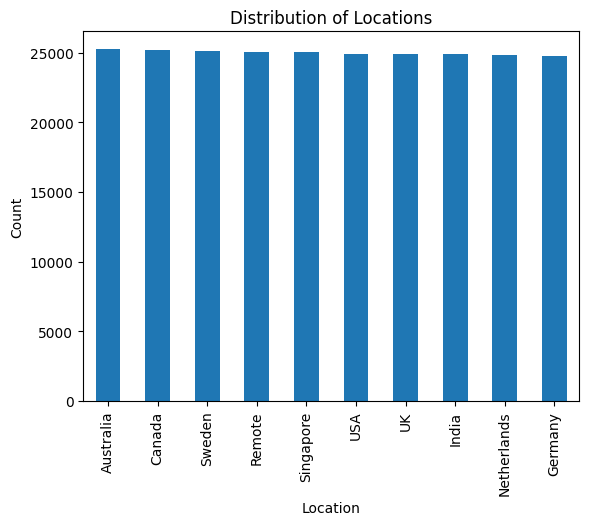

In [6]:
locatin_counts = df['location'].value_counts()
locatin_counts.plot(kind='bar')
plt.xlabel('Location')
plt.ylabel('Count')
plt.title('Distribution of Locations')
plt.show()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [8]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

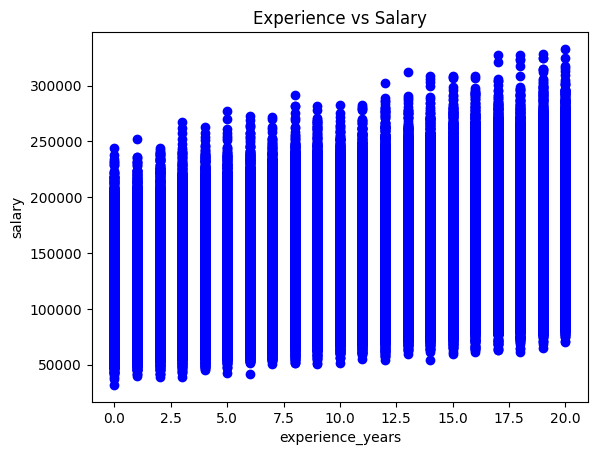

In [9]:
plt.scatter(df['experience_years'],df['salary'],color='blue',marker='o')
plt.xlabel('experience_years')
plt.ylabel('salary')
plt.title('Experience vs Salary')
plt.show()

In [10]:
df[['experience_years','certifications','skills_count','salary']].corr()

,experience_years,certifications,skills_count,salary
experience_years,1.000000,-0.000198,0.000149,0.437627
certifications,-0.000198,1.000000,-0.002230,0.073819
skills_count,0.000149,-0.002230,1.000000,0.127300
salary,0.437627,0.073819,0.127300,1.000000


In [11]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [12]:
cols = ['education_level','company_size','industry','remote_work','job_title','location']

df = pd.get_dummies(df,columns = cols,drop_first=True)

In [13]:
x = df.drop('salary',axis=1)
y = df['salary']

In [14]:
import joblib



joblib.dump(x.columns, 'columns.pkl')

['columns.pkl']

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [16]:
import sklearn.model_selection
model = sklearn.ensemble.RandomForestRegressor(n_estimators=30,max_depth=25, random_state=42)

In [17]:
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",25
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [18]:
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.989393472308706
0.9576897594378544


In [19]:

y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)




Mean Squared Error: 58805464.69682515
R-squared: 0.9576897594378544


In [20]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model,x,y,cv=5,scoring='r2',n_jobs=-1)
print(scores)
print ("Average R-squared:", np.mean(scores))

KeyboardInterrupt: 

In [ ]:
feat = pd.Series(model.feature_importances_,index=x.columns)
print(feat.sort_values(ascending = False).head(10))

experience_years              0.201200
location_India                0.182730
location_USA                  0.076472
company_size_Startup          0.061423
education_level_PhD           0.061165
company_size_Small            0.051274
job_title_Data Analyst        0.044950
company_size_Medium           0.043998
job_title_Business Analyst    0.042767
location_Canada               0.034689
dtype: float64


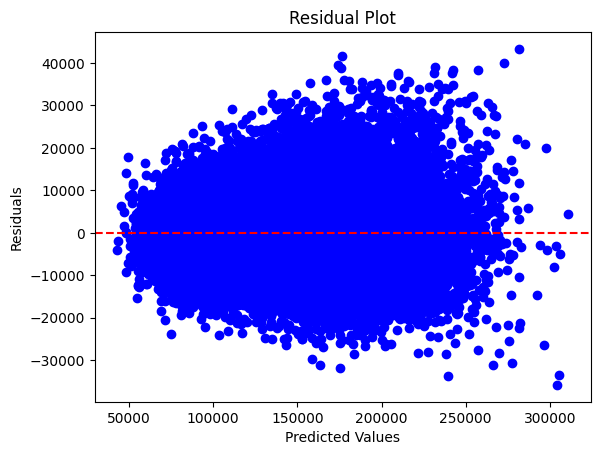

In [ ]:
error = y_test-y_pred
plt.scatter(y_pred,error,color='blue',marker='o')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(y=0,color='red',linestyle='--')
plt.show()

<Axes: ylabel='salary'>

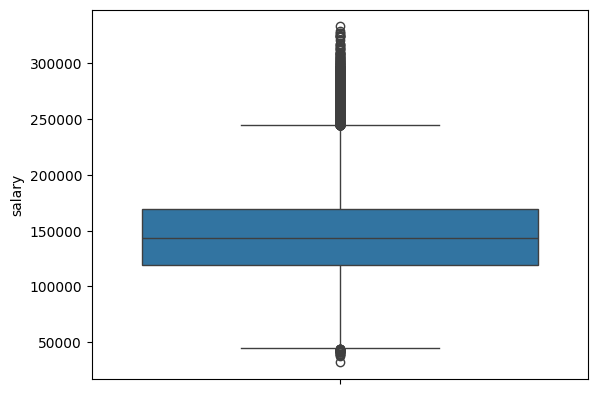

In [ ]:
sns.boxplot(y)

In [ ]:
import joblib
joblib.dump(model,'Salary_prediction.pkl',compress=3)

['Salary_prediction.pkl']